Detecting gaze/comp trials 
#version 2.0 (04/25/2025 by JS)

In [1]:
# import modules 

import os
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
import scipy as sp
import scipy.interpolate
from matplotlib import pyplot as plt
from datetime import datetime
from time import time
import matplotlib.patches as mpatches
import cv2
import subprocess
from scipy import stats
import sklearn.neighbors
import sklearn.linear_model

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [4]:
# import functions

def drop_nearby_events(thin, avoid, win=0.25):
    """Drop events that fall near others.

    When eliminating compensatory eye/head movements which fall right after
    gaze-shifting eye/head movements, `thin` should be the compensatory event
    times.

    Parameters
    ----------
    thin : np.array
        Array of timestamps (as float in units of seconds) that
        should be thinned out, removing any timestamps that fall
        within `win` seconds of timestamps in `avoid`.
    avoid : np.array
        Timestamps to avoid being near.
    win : np.array
        Time (in seconds) that times in `thin` must fall before or
        after items in `avoid` by.
    
    """

    to_drop = np.array([c for c in thin for g in avoid if ((g>(c-win)) & (g<(c+win)))])
    thinned = np.delete(thin, np.isin(thin, to_drop))

    return thinned


def drop_repeat_events(eventT, onset=True, win=0.020):
    """Eliminate saccades repeated over sequential camera frames.

    Saccades sometimes span sequential camera frames, so that two or
    three sequential camera frames are labaled as saccade events, despite
    only being a single eye/head movement. This function keeps only a
    single frame from the sequence, either the first or last in the
    sequence.

    Parameters
    ----------
    eventT : np.array
        Array of saccade times (in seconds as float).
    onset : bool
        If True, a sequence of back-to-back frames labeled as a saccade will
        be reduced to only the first/onset frame in the sequence. If false, the
        last in the sequence will be used.
    win : float
        Distance in time (in seconds) that frames must follow each other to be
        considered repeating. Frames are 0.016 ms, so the default value, 0.020
        requires that frames directly follow one another.

    Returns
    -------
    thinned : np.array
        Array of saccade times, with repeated labels for single events removed.

    """

    duplicates = set([])

    for t in eventT:

        if onset:
            # keep first
            new = eventT[((eventT-t)<win) & ((eventT-t)>0)]
        
        else:
            # keep last
            new = eventT[((t-eventT)<win) & ((t-eventT)>0)]
        duplicates.update(list(new))

    thinned = np.sort(np.setdiff1d(eventT, np.array(list(duplicates)), assume_unique=True))
    
    return thinned


def read_timestamp_series(s):
    """ Read timestamps as a pd.Series and format time.

    Parameters
    ----------
    s : pd.Series
        Timestamps as a Series. Expected to be formated as
        hours:minutes:seconds.microsecond

    Returns
    -------
    output_time : np.array
        Returned as the number of seconds that have passed since the
        previous midnight, with microescond precision, e.g. 700.000000

    """

    # Expected string format for timestamps.
    fmt = '%H:%M:%S.%f'

    output_time = []

    if s.dtype != np.float64:

        for current_time in s:

            str_time = str(current_time).strip()

            try:
                t = datetime.strptime(str_time, fmt)

            except ValueError as v:
                # If the string had unexpected characters (too much precision) for
                # one timepoint, drop the extra characters.

                ulr = len(v.args[0].partition('unconverted data remains: ')[2])
                
                if ulr:
                    str_time = str_time[:-ulr]
            
            try:
                output_time.append(
                        (datetime.strptime(str_time, '%H:%M:%S.%f')
                            - datetime.strptime('00:00:00.000000', '%H:%M:%S.%f')
                            ).total_seconds())

            except ValueError:
                output_time.append(np.nan)

        output_time = np.array(output_time)

    else:
        output_time = s.values

    return output_time


def deinterlace(vidfile, savepath, exp_fps=30, quiet=True):
    """ Deinterlace a video.

    Parameters
    ----------
    path : str
        Path to the video file.
    savepath : str
        Path to save the new video file. Default is None.
    rotate : bool
        Whether to rotate the video 180 degrees. Default is True.
    exp_fps : int
        Expected frame rate of the video. If the video matches
        this frame rate (in Hz), it will be deinterlaced. Otherwise,
        it will be skipped. Default is 30 Hz.
    quiet : bool
        Whether to suppress the output from ffmpeg. Default is True.
    
    Returns
    -------
    savepath : str
        Path to the new video file.

    """

    # Open video, get frame count and rate
    cap = cv2.VideoCapture(vidfile)
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Skip this video if it doesn't match the expected frame rate.
    if fps != exp_fps:
        return
        
    # Create the FFMPEG commands for video rotation.
    vf_val = 'yadif=1:-1:0, vflip, hflip, scale=640:480'

    # Create the full FFMPEG command
    cmd = ['ffmpeg', '-i', vidfile, '-vf', vf_val, '-c:v', 'libx264',
          '-preset', 'slow', '-crf', '19', '-c:a', 'aac', '-b:a',
          '256k', '-y', savepath]
    
    # Set the log level
    if quiet is True:
        cmd.extend(['-loglevel', 'quiet'])

    # Run the FFMPEG command.
    subprocess.call(cmd)

    return savepath


def interp_timestamps(camT, use_medstep=False):
    """ Interpolate timestamps for double the number of
    frames. Compensates for video deinterlacing.
    
    Parameters
    ----------
    camT : np.array
        Camera timestamps aquired at 30Hz
    use_medstep : bool
        When True, the median diff(camT) will be used as the timestep
        in interpolation. If False, the timestep between each frame
        will be used instead.

    Returns
    -------
    camT_out : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array. Each timestamp in camT will
        be replaced by two, set equal distances from the original.

    """

    camT_out = np.zeros(np.size(camT, 0)*2)
    medstep = np.nanmedian(np.diff(camT, axis=0))

    if use_medstep:
        
        # Shift each deinterlaced frame by 0.5 frame periods
        # forward/backwards assuming a constant framerate

        camT_out[::2] = camT - 0.25 * medstep
        camT_out[1::2] = camT + 0.25 * medstep
    
    elif not use_medstep:

        # Shift each deinterlaced frame by the actual time between
        # frames. If a camera frame was dropped, this approach will
        # be more accurate than `medstep` above.
        
        steps = np.diff(camT, axis=0, append=camT[-1]+medstep)
        camT_out[::2] = camT
        camT_out[1::2] = camT + 0.5 * steps

    return camT_out


def nanxcorr(x, y, maxlag=25):
    """ Cross correlation ignoring NaNs.

    Parameters
    ----------
    x : array
        Array of values.
    y : array
        Array of values to shift. Must be same length as x.
    maxlag : int
        Number of lags to shift y prior to testing correlation.
    
    Returns
    -------
    cc_out : array
        Cross correlation.
    lags : range
        Lag vector.

    """

    lags = range(-maxlag, maxlag)
    cc = []

    for i in range(0,len(lags)):
        
        # shift data
        yshift = np.roll(y, lags[i])
        
        # get index where values are usable in both x and yshift
        use = ~pd.isnull(x + yshift)
        
        # some restructuring
        x_arr = np.asarray(x, dtype=object)
        yshift_arr = np.asarray(yshift, dtype=object)

        x_use = x_arr[use]
        yshift_use = yshift_arr[use]
        
        # normalize
        x_use = (x_use - np.mean(x_use)) / (np.std(x_use) * len(x_use))

        yshift_use = (yshift_use - np.mean(yshift_use)) / np.std(yshift_use)
        
        # get correlation
        cc.append(np.correlate(x_use, yshift_use))

    cc_out = np.hstack(np.stack(cc))
    
    return cc_out, lags

def read_timestamp_file(timestamp_path,position_data_length=None,
                        force_timestamp_shift=False):
    """ Read timestamps from a .csv file.

    Parameters
    ----------
    position_data_length : None or int
        Number of timesteps in data from deeplabcut. This is used to
        determine whether or not the number of timestamps is too short
        for the number of video frames.
        Eyecam and Worldcam will have half the number of timestamps as
        the number of frames, since they are aquired as an interlaced
        video and deinterlaced in analysis. To fix this, timestamps need
        to be interpolated.
    force_timestamp_shift : bool
        When True, the timestamps will be interpolated regardless of
        whether or not the number of timestamps is too short for the
        number of frames. Default is False.

    Returns
    -------
    camT : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array than there were in the provided
        csv file.

    """

    # Read data and set up format
    s = pd.read_csv(timestamp_path, encoding='utf-8',
                    engine='c', header=None).squeeze()
    
    # If the csv file has a header name for the column, (which is
    # is the int 0 for some early recordings), remove it.
    if s[0] == 0:
        s = s[1:]
    
    # Read the timestamps as a series and format them
    camT = read_timestamp_series(s)
    
    # Auto check if vids were deinterlaced
    if position_data_length is not None:

        if position_data_length > len(camT):

            # If the number of timestamps is too short for the number
            # of frames, interpolate the timestamps.

            camT = interp_timestamps(camT, use_medstep=False)
    
    # Force the times to be shifted if the user is sure it should be done
    if force_timestamp_shift is True:

        camT = interp_timestamps(camT, use_medstep=False)
    
    return camT


class Kalman():
    """ Kalman filter.

    From https://github.com/wehr-lab/autopilot/tree/parallax
    """

    def __init__(self, dim_state: int, dim_measurement: int = None, dim_control: int=0,
                 *args, **kwargs):

        self.dim_state = dim_state # type: int
        if dim_measurement is None:
            self.dim_measurement = self.dim_state # type: int
        else:
            self.dim_measurement = dim_measurement # type: int
        self.dim_control = dim_control # type: int

        self._init_arrays()

    def _init_arrays(self, state=None):
        """
        Initialize the arrays
        """
        # State arrays
        if state is not None:
            # TODO: check it's the right shape
            self.x_state = state
        else:
            self.x_state = np.zeros((self.dim_state, 1))

        # initialize kalman arrays
        self.P_cov               = np.eye(self.dim_state)                           # uncertainty covariance
        self.Q_proc_var          = np.eye(self.dim_state)                           # process uncertainty
        self.B_control           = np.eye(self.dim_control)                         # control transition matrix
        self.F_state_trans       = np.eye(self.dim_state)                           # x_state transition matrix
        if self.dim_state == self.dim_measurement:
            self.H_measure = np.eye(self.dim_measurement)
        else:
            self.H_measure           = np.zeros((self.dim_measurement, self.dim_state)) # measurement function
        self.R_measure_var       = np.eye(self.dim_measurement)                     # measurement uncertainty
        self._alpha_sq           = 1.                                               # fading memory control
        self.M_proc_measure_xcor = np.zeros((self.dim_state, self.dim_measurement)) # process-measurement cross correlation
        self.z_measure           = np.array([[None] * self.dim_measurement]).T

        # gain and residual are computed during the innovation step. We
        # save them so that in case you want to inspect them for various
        # purposes
        self.K = np.zeros((self.dim_state, self.dim_measurement)) # kalman gain
        self.y = np.zeros((self.dim_measurement, 1))
        self.S = np.zeros((self.dim_measurement, self.dim_measurement)) # system uncertainty
        self.SI = np.zeros((self.dim_measurement, self.dim_measurement)) # inverse system uncertainty

        # identity matrix. Do not alter this.
        self._I = np.eye(self.dim_state)

        # these will always be a copy of x_state,P_cov after predict() is called
        self.x_prior = self.x_state.copy()
        self.P_prior = self.P_cov.copy()

        # these will always be a copy of x_state,P_cov after update() is called
        self.x_post = self.x_state.copy()
        self.P_post = self.P_cov.copy()

    def predict(self, u=None, B=None, F=None, Q=None):
        """
        Predict next x_state (prior) using the Kalman filter x_state propagation
        equations.

        Parameters
        ----------

        u : np.array, default 0
            Optional control vector.

        B : np.array(dim_state, dim_u), or None
            Optional control transition matrix; a value of None
            will cause the filter to use `self.B_control`.

        F : np.array(dim_state, dim_state), or None
            Optional x_state transition matrix; a value of None
            will cause the filter to use `self.F_state_trans`.

        Q : np.array(dim_state, dim_state), scalar, or None
            Optional process noise matrix; a value of None will cause the
            filter to use `self.Q_proc_var`.
        """
        if B is None:
            B = self.B_control
        if F is None:
            F = self.F_state_trans
        if Q is None:
            Q = self.Q_proc_var
        elif np.isscalar(Q):
            Q = np.eye(self.dim_state) * Q

        # x_state = Fx + Bu
        if B is not None and u is not None:
            # make sure control vector is column
            u = np.atleast_2d(u)
            if u.shape[1] > u.shape[0]:
                u = u.T
            self.x_state = np.dot(F, self.x_state) + np.dot(B, u)
        else:
            self.x_state = np.dot(F, self.x_state)

        # P_cov = FPF' + Q_proc_var
        self.P_cov = self._alpha_sq * np.dot(np.dot(F, self.P_cov), F.T) + Q

        # save prior
        np.copyto(self.x_prior, self.x_state)
        np.copyto(self.P_prior, self.P_cov)

    def update(self, z, R=None, H=None):
        """
        Add a new measurement (z_measure) to the Kalman filter.

        If z_measure is None, nothing is computed. However, x_post and P_post are
        updated with the prior (x_prior, P_prior), and self.z_measure is set to None.

        Parameters
        ----------
        z : (dim_measurement, 1): array_like
            measurement for this update. z_measure can be a scalar if dim_measurement is 1,
            otherwise it must be convertible to a column vector.

            If you pass in a value of H_measure, z_measure must be a column vector the
            of the correct size.

        R : np.array, scalar, or None
            Optionally provide R_measure_var to override the measurement noise for this
            one call, otherwise  self.R_measure_var will be used.

        H : np.array, or None
            Optionally provide H_measure to override the measurement function for this
            one call, otherwise self.H_measure will be used.
        """
        # set to None to force recompute
        self._log_likelihood = None
        self._likelihood = None
        self._mahalanobis = None

        if z is None:
            self.z_measure = np.array([[None] * self.dim_measurement]).T
            np.copyto(self.x_post, self.x_state)
            np.copyto(self.P_post, self.P_cov)
            self.y = np.zeros((self.dim_measurement, 1))
            return

        if R is None:
            R = self.R_measure_var
        elif np.isscalar(R):
            R = np.eye(self.dim_measurement) * R

        if H is None:
            z = self._reshape_z(z, self.dim_measurement, self.x_state.ndim)
            H = self.H_measure

        # y = z_measure - Hx
        # error (residual) between measurement and prediction
        self.y = z - np.dot(H, self.x_state)

        # common subexpression for speed
        PHT = np.dot(self.P_cov, H.T)

        # S = HPH' + R_measure_var
        # project system uncertainty into measurement space
        self.S = np.dot(H, PHT) + R
        self.SI = np.linalg.inv(self.S)
        # K = PH'inv(S)
        # map system uncertainty into kalman gain
        self.K = np.dot(PHT, self.SI)

        # x_state = x_state + Ky
        # predict new x_state with residual scaled by the kalman gain
        self.x_state = self.x_state + np.dot(self.K, self.y)

        # P_cov = (I-KH)P_cov(I-KH)' + KRK'
        # This is more numerically stable
        # and works for non-optimal K vs the equation
        # P_cov = (I-KH)P_cov usually seen in the literature.

        I_KH = self._I - np.dot(self.K, H)
        self.P_cov = np.dot(np.dot(I_KH, self.P_cov), I_KH.T) + np.dot(np.dot(self.K, R), self.K.T)

        # save measurement and posterior x_state
        np.copyto(self.z_measure, z)
        np.copyto(self.x_post, self.x_state)
        np.copyto(self.P_post, self.P_cov)
        return self.x_state

    def _reshape_z(self, z, dim_z, ndim):
        """ ensure z is a (dim_z, 1) shaped vector"""

        z = np.atleast_2d(z)
        if z.shape[1] == dim_z:
            z = z.T

        if z.shape != (dim_z, 1):
            raise ValueError('z (shape {}) must be convertible to shape ({}, 1)'.format(z.shape, dim_z))

        if ndim == 1:
            z = z[:, 0]

        if ndim == 0:
            z = z[0, 0]

        return z

    def process(self, z, **kwargs):
        """
        Call predict and update, passing the relevant kwargs

        Args:
            z ():
            **kwargs ():

        Returns:
            np.ndarray: self.x_state
        """

        # prepare args for predict and call
        predict_kwargs = {k:kwargs.get(k, None) for k in ("u", "B", "F", "Q")}
        self.predict(**predict_kwargs)

        # same thing for update
        update_kwargs = {k: kwargs.get(k, None) for k in ('R', 'H')}
        return self.update(z, **update_kwargs)

    def residual_of(self, z):
        """
        Returns the residual for the given measurement (z_measure). Does not alter
        the x_state of the filter.
        """
        return z - np.dot(self.H_measure, self.x_prior)

    def measurement_of_state(self, x):
        """
        Helper function that converts a x_state into a measurement.

        Parameters
        ----------

        x : np.array
            kalman x_state vector

        Returns
        -------

        z_measure : (dim_measurement, 1): array_like
            measurement for this update. z_measure can be a scalar if dim_measurement is 1,
            otherwise it must be convertible to a column vector.
        """

        return np.dot(self.H_measure, x)

    @property
    def alpha(self):
        """
        Fading memory setting. 1.0 gives the normal Kalman filter, and
        values slightly larger than 1.0 (such as 1.02) give a fading
        memory effect - previous measurements have less influence on the
        filter's estimates. This formulation of the Fading memory filter
        (there are many) is due to Dan Simon [1]_.
        """
        return self._alpha_sq**.5

    @alpha.setter
    def alpha(self, value):
        if not np.isscalar(value) or value < 1:
            raise ValueError('alpha must be a float greater than 1')

        self._alpha_sq = value**2

class ImuOrientation():
    """ IMU sensor fusion

    From https://github.com/wehr-lab/autopilot/tree/parallax

    Compute absolute orientation (roll, pitch) from accelerometer and gyroscope measurements
    (eg from :class:`.hardware.i2c.I2C_9DOF` )

    Uses a :class:`.timeseries.Kalman` filter, and implements :cite:`patonisFusionMethodCombining2018a` to fuse
    the sensors

    Can be used with accelerometer data only, or with combined accelerometer/gyroscope data for
    greater accuracy

    Arguments:
        invert_gyro (bool): if the gyroscope's orientation is inverted from accelerometer measurement, multiply
            gyro readings by -1 before using
        use_kalman (bool): Whether to use kalman filtering (True, default), or return raw trigonometric
            transformation of accelerometer readings (if provided, gyroscope readings will be ignored)

    Attributes:
        kalman (:class:`.transform.timeseries.Kalman`): If ``use_kalman == True`` , the Kalman Filter.

    References:
        :cite:`patonisFusionMethodCombining2018a`
        :cite:`abyarjooImplementingSensorFusion2015`
    """

    def __init__(self, use_kalman:bool = True, invert_gyro:bool=False, *args, **kwargs):

        self.invert_gyro = invert_gyro # type: bool
        self._last_update = None # type: typing.Optional[float]
        self._dt = 0 # type: float
        # preallocate orientation array for filtered values
        self.orientation = np.zeros((2), dtype=float) # type: np.ndarray
        # and for unfiltered values so they aren't ambiguous
        self._orientation = np.zeros((2), dtype=float)  # type: np.ndarray

        self.kalman = None # type: typing.Optional[Kalman]
        if use_kalman:
            self.kalman = Kalman(dim_state=2, dim_measurement=2, dim_control=2)  # type: typing.Optional[Kalman]

    def process(self, accelgyro):
        """

        Args:
            accelgyro (tuple, :class:`numpy.ndarray`): tuple of (accelerometer[x,y,z], gyro[x,y,z]) readings as arrays, or
                an array of just accelerometer[x,y,z]

        Returns:
            :class:`numpy.ndarray`: filtered [roll, pitch] calculations in degrees
        """
        # check what we were given...
        if isinstance(accelgyro, (tuple, list)) and len(accelgyro) == 2:
            # combined accelerometer and gyroscope readings
            accel, gyro = accelgyro
        elif isinstance(accelgyro, np.ndarray) and np.squeeze(accelgyro).shape[0] == 3:
            # just accelerometer readings
            accel = accelgyro
            gyro = None
        else:
            # idk lol
            # self.logger.exception(f'Need input to be a tuple of accelerometer and gyroscope readings, or an array of accelerometer readings. got {accelgyro}')
            print('Error')
            return

        # convert accelerometer readings to roll and pitch
        pitch = 180*np.arctan2(accel[0], np.sqrt(accel[1]**2 + accel[2]**2))/np.pi
        roll = 180*np.arctan2(accel[1], np.sqrt(accel[0]**2 + accel[2]**2))/np.pi

        if self.kalman is None:
            # store orientations in external attribute if not using kalman filter
            self.orientation[:] = (roll, pitch)
            return self.orientation.copy()
        else:
            # if using kalman filter, use private array to store raw orientation
            self._orientation[:] = (roll, pitch)

        # TODO: Don't assume that we're fed samples instantatneously -- ie. once data representations are stable, need to accept a timestamp here rather than making one
        if self._last_update is None or gyro is None:
            # first time through don't have dt to scale gyro by
            self.orientation[:] = np.squeeze(self.kalman.process(self._orientation))
            self._last_update = time()
        else:
            if self.invert_gyro:
                gyro *= -1

            # get dt for time since last update
            update_time = time()
            self._dt = update_time-self._last_update
            self._last_update = update_time

            if self._dt>1:
                # if it's been really long, the gyro read is pretty much useless and will give ridiculous reads
                self.orientation[:] = np.squeeze(self.kalman.process(self._orientation))
            else:
                # run predict and update stages separately to incorporate gyro
                self.kalman.predict(u=gyro[0:2]*self._dt)
                self.orientation[:] = np.squeeze(self.kalman.update(self._orientation))

        return self.orientation.copy()
    

def open_dlc_h5(dlc_path):
    """ Open the .h5 file generated by DLC.

    Parameters
    ----------
    h5key : str
        The key to the .h5 file. Default is None.

    """
    
    pts = pd.read_hdf(dlc_path)
    
    # organize columns
    pts.columns = [' '.join(col[:][1:3]).strip() for col in pts.columns.values]
    
    pts = pts.rename(columns={pts.columns[n]: pts.columns[n].replace(' ', '_') for n in range(len(pts.columns))})
    pt_loc_names = pts.columns.values
    return pts, pt_loc_names


def fit_ellipse(x, y):
    """ Fit an ellipse to points labeled around the perimeter of pupil.

    Parameters
    ----------
    x : np.array
        Positions of points along the x-axis for a single video frame.
    y : np.array
        Positions of labeled points along the y-axis for a single video frame.

    Returns
    -------
    ellipse_dict : dict
        Parameters of the ellipse...
        X0 : center at the x-axis of the non-tilt ellipse
        Y0 : center at the y-axis of the non-tilt ellipse
        a : radius of the x-axis of the non-tilt ellipse
        b : radius of the y-axis of the non-tilt ellipse
        long_axis : radius of the long axis of the ellipse
        short_axis : radius of the short axis of the ellipse
        angle_to_x : angle from long axis to horizontal plane
        angle_from_x : angle from horizontal plane to long axis
        X0_in : center at the x-axis of the tilted ellipse
        Y0_in : center at the y-axis of the tilted ellipse
        phi : tilt orientation of the ellipse in radians

    """

    # Remove bias of the ellipse
    meanX = np.mean(x)
    meanY = np.mean(y)
    x = x - meanX
    y = y - meanY

    # Estimation of the conic equation
    X = np.array([x**2, x*y, y**2, x, y])
    X = np.stack(X).T
    a = np.dot(np.sum(X, axis=0), np.linalg.pinv(np.matmul(X.T,X)))

    # Extract parameters from the conic equation
    a, b, c, d, e = a[0], a[1], a[2], a[3], a[4]

    # Eigen decomp
    Q = np.array([[a, b/2],[b/2, c]])
    eig_val, eig_vec = np.linalg.eig(Q)

    # Get angle to long axis
    if eig_val[0] < eig_val[1]:
        angle_to_x = np.arctan2(eig_vec[1,0], eig_vec[0,0])
    else:
        angle_to_x = np.arctan2(eig_vec[1,1], eig_vec[0,1])

    angle_from_x = angle_to_x
    orientation_rad = 0.5 * np.arctan2(b, (c-a))
    cos_phi = np.cos(orientation_rad)
    sin_phi = np.sin(orientation_rad)

    a, b, c, d, e = [a*cos_phi**2 - b*cos_phi*sin_phi + c*sin_phi**2,
                    0,
                    a*sin_phi**2 + b*cos_phi*sin_phi + c*cos_phi**2,
                    d*cos_phi - e*sin_phi,
                    d*sin_phi + e*cos_phi]

    meanX, meanY = [cos_phi*meanX - sin_phi*meanY,
                    sin_phi*meanX + cos_phi*meanY]

    # Check if conc expression represents an ellipse
    test = a*c

    if test > 0:

        # Make sure coefficients are positive
        if a<0:
            a, c, d, e = [-a, -c, -d, -e]

        # Final ellipse parameters
        X0 = meanX - d/2/a
        Y0 = meanY - e/2/c
        F = 1 + (d**2)/(4*a) + (e**2)/(4*c)
        a = np.sqrt(F/a)
        b = np.sqrt(F/c)
        long_axis = 2*np.maximum(a,b)
        short_axis = 2*np.minimum(a,b)

        # Rotate axes backwards to find center point of
        # original tilted ellipse
        R = np.array([[cos_phi, sin_phi], [-sin_phi, cos_phi]])
        P_in = R @ np.array([[X0],[Y0]])
        X0_in = P_in[0][0]
        Y0_in = P_in[1][0]

        # Organize parameters in dictionary to return
        ellipse_dict = {
            'X0':X0,
            'Y0':Y0,
            'F':F,
            'a':a,
            'b':b,
            'long_axis':long_axis/2,
            'short_axis':short_axis/2,
            'angle_to_x':angle_to_x,
            'angle_from_x':angle_from_x,
            'cos_phi':cos_phi,
            'sin_phi':sin_phi,
            'X0_in':X0_in,
            'Y0_in':Y0_in,
            'phi':orientation_rad
        }

    else:

        # If the conic equation didn't return an ellipse, do not
        # return any real values and fill the dictionary with NaNs.
        dict_keys = ['X0','Y0','F','a','b','long_axis',
                        'short_axis','angle_to_x','angle_from_x',
                        'cos_phi','sin_phi','X0_in','Y0_in','phi']
        dict_vals = list(np.ones([len(dict_keys)]) * np.nan)

        ellipse_dict = dict(zip(dict_keys, dict_vals))
    
    return ellipse_dict



Import data (IMU and eye files) & detect gaze/comp trials

In [5]:

#session information 

session_date = '050625' 
animal_ID = 'imu__test1'
session_ID = 'oa_cam1'
Rig_ID = 'Rig2'

#import IMU data  

imu_timestamps_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) + '_control_Rig2_' + str(session_ID) + '_Ephys_BonsaiBoardTS.csv'
imu_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) + '_control_Rig2_' + str(session_ID) + '_IMU.bin'

# Set up datatypes and names for each channel
dtypes = np.dtype([
    ("acc_x",np.uint16),
    ("acc_y",np.uint16),
    ("acc_z",np.uint16),
    ("none1",np.uint16),
    ("gyro_x",np.uint16),
    ("gyro_y",np.uint16),
    ("gyro_z",np.uint16),
    ("none2",np.uint16)
])


binary_in = pd.DataFrame(np.fromfile(imu_path, dtypes, -1, ''))
binary_in = binary_in.drop(columns=['none1','none2'])


# Convert to - 5V to + 5V (from ints)
data = 10 * (binary_in.astype(float)/(2**16) - 0.5)

# Downsample in time dimension
imu_samprate = 30000 # fixed constant
imu_dwnsmpl = 100 # imu_samprate is 30000, and we are using 100, therefore making it 30000/100 = 300hz. 
                  # if you want to boost up the temporal resolution up to 500hz, you can use 60.

data = data.iloc[::imu_dwnsmpl]

# Calculate new sample rate
samp_freq = imu_samprate / imu_dwnsmpl

# Alphabetize columns
data = data.reindex(sorted(data.columns), axis=1)

# Read in timestamps
csv_data = pd.read_csv(imu_timestamps_path).squeeze()
pdtime = pd.DataFrame(read_timestamp_series(csv_data))

# Get first/last timepoint, num_samples
t0 = pdtime.iloc[0,0]
num_samp = np.size(data,0)

# Samples start at t0, and are acquired at rate of
# 'ephys_sample_rate'/ 'imu_downsample'
newtime = list(np.array(t0 + np.linspace(0, num_samp-1, num_samp) / samp_freq))


IMU = ImuOrientation()

# Convert accelerometer to g
zero_reading = 2.9
sensitivity = 1.6
acc = pd.DataFrame.to_numpy((data[['acc_x', 'acc_y', 'acc_z']]-zero_reading)*sensitivity)

# Convert gyro to deg/sec
gyro = pd.DataFrame.to_numpy((data[['gyro_x', 'gyro_y', 'gyro_z']] - pd.DataFrame.mean(data[['gyro_x', 'gyro_y', 'gyro_z']]))*400)

# Collect roll & pitch
roll_pitch = np.zeros([len(acc),2])
for x in range(len(acc)):
    roll_pitch[x,:] = IMU.process((acc[x],gyro[x])) # update by row
roll_pitch = pd.DataFrame(roll_pitch, columns=['roll','pitch'])

# Collect the data together
all_data = pd.concat([
    data.reset_index(),
    pd.DataFrame(acc).reset_index(),
    pd.DataFrame(gyro).reset_index(),
    roll_pitch
], axis=1).drop(labels='index',axis=1)

# Set up column names
all_data.columns = [
    'acc_x_raw','acc_y_raw','acc_z_raw',
    'gyro_x_raw','gyro_y_raw','gyro_z_raw',
    'acc_x','acc_y','acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch'
]


"\\goeppert\Vol2\mike\recordings\050625\imu__test1\oa_cam1\050625_imu__test1_control_Rig2_oa_cam1_IMU.bin"

Text(0.5, 0, 'frame')

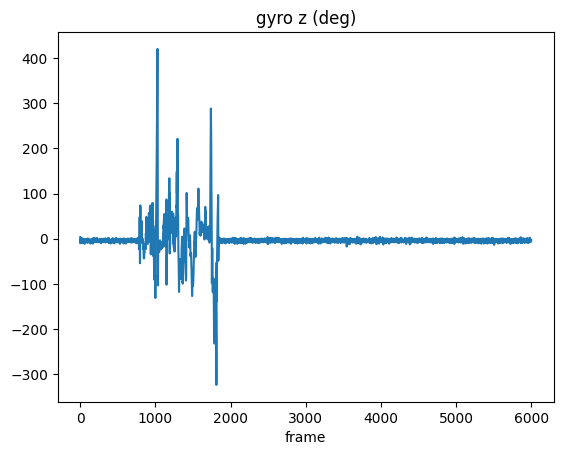

In [6]:
output_data = xr.DataArray(all_data, dims=['sample','channel'])
imu_data = output_data.assign_coords({'sample':newtime})

imuT_raw = imu_data.sample # imu timestamps

# Raw gyro values
gyro_x_raw = imu_data.sel(channel='gyro_x_raw').values
gyro_y_raw = imu_data.sel(channel='gyro_y_raw').values
gyro_z_raw = imu_data.sel(channel='gyro_z_raw').values

# Gyro values in degrees
gyro_x = imu_data.sel(channel='gyro_x').values
gyro_y = imu_data.sel(channel='gyro_y').values
gyro_z = imu_data.sel(channel='gyro_z').values

# Pitch and roll in deg
roll = imu_data.sel(channel='roll').values
pitch = imu_data.sel(channel='pitch').values

# figure of gyro z
plt.figure()
plt.plot(gyro_x[0:100*60])
plt.title('gyro z (deg)')
plt.xlabel('frame')

In [ ]:
np.linspace(imuT_raw - np.nanmin(imuT_raw),int(np.nanmax(imuT_raw)), int(len(imuT_raw)/300))

array([    0.        ,    90.16830065,   180.33660131,   270.50490196,
         360.67320261,   450.84150327,   541.00980392,   631.17810458,
         721.34640523,   811.51470588,   901.68300654,   991.85130719,
        1082.01960784,  1172.1879085 ,  1262.35620915,  1352.5245098 ,
        1442.69281046,  1532.86111111,  1623.02941176,  1713.19771242,
        1803.36601307,  1893.53431373,  1983.70261438,  2073.87091503,
        2164.03921569,  2254.20751634,  2344.37581699,  2434.54411765,
        2524.7124183 ,  2614.88071895,  2705.04901961,  2795.21732026,
        2885.38562092,  2975.55392157,  3065.72222222,  3155.89052288,
        3246.05882353,  3336.22712418,  3426.39542484,  3516.56372549,
        3606.73202614,  3696.9003268 ,  3787.06862745,  3877.2369281 ,
        3967.40522876,  4057.57352941,  4147.74183007,  4237.91013072,
        4328.07843137,  4418.24673203,  4508.41503268,  4598.58333333,
        4688.75163399,  4778.91993464,  4869.08823529,  4959.25653595,
      

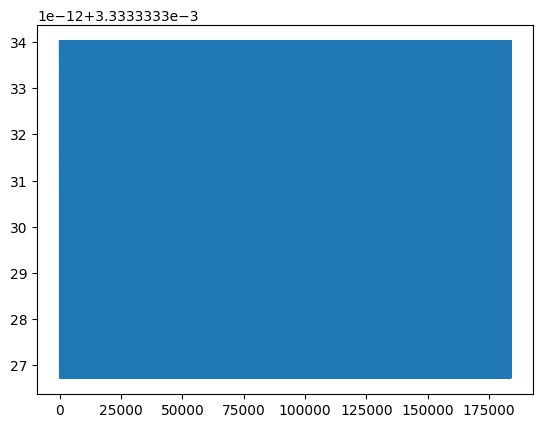

In [ ]:
plt.plot(len(np.diff(imuT_raw)),np.diff(imuT_raw))

In [82]:
pt_loc

'spot_cent_y'

In [ ]:
#import raw EYE video data
#vidfile = 'T:/freely_moving_ephys/nn_dataset/070921_J553RT/fm1/070921_J553RT_control_Rig2_fm1_REYE.avi'

#assign deinterlaced video filepath
#savepath = 'T:/freely_moving_ephys/nn_dataset/070921_J553RT/fm1/070921_J553RT_control_Rig2_fm1_REYEdeinter.avi'

#Procecss deinterlace and save it to the savepath 
#deinterlace(vidfile, savepath, exp_fps=30, quiet=True)

#DLC tracking 

#run DLC network for the deinterlaced video HERE 
#Once you add dlc process here, you don't really need a bottom line.

dlc_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000.h5'
eye_timestamp_path =  '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_REYE_BonsaiTS.csv'

pts, pt_names = open_dlc_h5(dlc_path)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])

data = xrpts
names = list(data['point_loc'].values)
thresh = 0.99 #configuration value

x_locs = []
y_locs = []
likeli_locs = []

# seperate the lists of point names into x, y, and likelihood
for loc_num in range(0, len(names)):
    loc = names[loc_num]
    if '_x' in loc:
        x_locs.append(loc)
    elif '_y' in loc:
        y_locs.append(loc)
    elif 'likeli' in loc:
        likeli_locs.append(loc)

# get the xarray, split up into x, y,and likelihood
for loc_num in range(0, len(likeli_locs)):
    pt_loc = likeli_locs[loc_num]
    if loc_num == 0:
        likeli_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        likeli_pts = xr.concat([likeli_pts, data.sel(point_loc=pt_loc)],
                                dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(x_locs)):
    pt_loc = x_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        x_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        x_pts = xr.concat([x_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(y_locs)):
    pt_loc = y_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        y_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        y_pts = xr.concat([y_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

x_pts = xr.DataArray.squeeze(x_pts)
y_pts = xr.DataArray.squeeze(y_pts)
likeli_pts = xr.DataArray.squeeze(likeli_pts)

# convert to dataframe, transpose so points are columns
x_vals = xr.DataArray.to_pandas(x_pts).T
print(x_vals) 
y_vals = xr.DataArray.to_pandas(y_pts).T
likeli_vals = xr.DataArray.to_pandas(likeli_pts).T
likelihood_in = likeli_vals.values

# Subtract center of IR light reflection from points around the pupil.

spot_xcent = np.mean(x_vals.iloc[:,-5:], 1)
spot_ycent = np.mean(y_vals.iloc[:,-5:], 1)
spot_likelihood = likelihood_in[:,-5:].copy()

likelihood = likelihood_in[:,:-5]

x_vals = x_vals.iloc[:,:-5].subtract(spot_xcent, axis=0)
y_vals = y_vals.iloc[:,:-5].subtract(spot_ycent, axis=0)

x_vals = x_vals.iloc[:,:-2]
y_vals = y_vals.iloc[:,:-2]
likelihood = likelihood[:,:-2]

pupil_count = np.sum(likelihood >= thresh, 1)

spot_count = np.sum(spot_likelihood >= thresh, 1)

usegood_eye = (pupil_count >= 7) &               \
                (spot_count >= 5)

usegood_eyecalib = (pupil_count >= 8) &          \
                    (spot_count >= 5)

usegood_reflec = (spot_count >=5)


# Threshold out pts more than a given distance away from nanmean of that point
std_thresh_x = np.empty(np.shape(x_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = x_vals.iloc[:,point_loc]
    std_thresh_x[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 24

std_thresh_y = np.empty(np.shape(y_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = y_vals.iloc[:,point_loc]
    std_thresh_y[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 4.1

std_thresh_x = np.nanmean(std_thresh_x, 1)
std_thresh_y = np.nanmean(std_thresh_y, 1)

x_vals[std_thresh_x > 0] = np.nan
y_vals[std_thresh_y > 0] = np.nan

cols = [
    'X0',           # 0
    'Y0',           # 1
    'F',            # 2
    'a',            # 3
    'b',            # 4
    'long_axis',    # 5
    'short_axis',   # 6
    'angle_to_x',   # 7
    'angle_from_x', # 8
    'cos_phi',      # 9
    'sin_phi',      # 10
    'X0_in',        # 11
    'Y0_in',        # 12
    'phi'           # 13
]


point_loc       pt1_x       pt2_x       pt3_x       pt4_x       pt5_x  \
frame                                                                   
0            5.446026    4.613894         NaN    1.269070         NaN   
1            5.446026    4.613894         NaN    1.269070         NaN   
2          337.180542  341.229736  373.718231  308.563049  363.585938   
3          338.868011  344.178925  377.645569  315.408020  366.662018   
4          337.488495  343.324615  375.724976  315.185272  364.882996   
...               ...         ...         ...         ...         ...   
86309      351.673401  359.831818  398.863007  318.520386  378.822418   
86310      351.758759  359.762482  398.773926  318.714233  378.846497   
86311      351.665344  359.724945  398.787781  318.724884  378.802307   
86312      351.738831  359.872498  398.893066  318.685242  378.846863   
86313      351.723755  359.770935  398.885864  318.695190  378.810669   

point_loc       pt6_x       pt7_x       pt8_x     

In [85]:
x_vals

point_loc,pt1_x,pt2_x,pt3_x,pt4_x,pt5_x,pt6_x,pt7_x,pt8_x
frame,,,,,,,,
0,0.907123,0.074991,NaN,-3.269833,NaN,-1.651149,-2.004837,1.745824
1,0.907123,0.074991,NaN,-3.269833,NaN,-1.651149,-2.004837,1.745824
2,-16.946375,-12.897180,19.591315,-45.563867,9.459021,-36.273218,14.690771,-32.034906
3,-17.665485,-12.354572,21.112073,-41.125476,10.128522,-34.167285,14.842725,-30.982959
4,-18.765546,-12.929425,19.470935,-41.068768,8.628955,-34.377362,13.201282,-31.679883
...,...,...,...,...,...,...,...,...
86309,-10.862317,-2.703900,36.327289,-44.015332,16.286700,-30.366864,31.060382,-29.498273
86310,-10.767883,-2.764160,36.247284,-43.812408,16.319855,-30.231689,30.988647,-29.349792
86311,-10.881940,-2.822339,36.240497,-43.822400,16.255023,-30.233350,30.950519,-29.417188


In [76]:
x_vals.iloc[:,-5:]

point_loc,pt4_x,pt5_x,pt6_x,pt7_x,pt8_x
frame,,,,,
0,-3.269833,NaN,-1.651149,-2.004837,1.745824
1,-3.269833,NaN,-1.651149,-2.004837,1.745824
2,-45.563867,9.459021,-36.273218,14.690771,-32.034906
3,-41.125476,10.128522,-34.167285,14.842725,-30.982959
4,-41.068768,8.628955,-34.377362,13.201282,-31.679883
...,...,...,...,...,...
86309,-44.015332,16.286700,-30.366864,31.060382,-29.498273
86310,-43.812408,16.319855,-30.231689,30.988647,-29.349792
86311,-43.822400,16.255023,-30.233350,30.950519,-29.417188


In [51]:
#Fit ellipse

ellipse = np.empty([len(usegood_eye), 14])

# Step through each frame, fit an ellipse to points, and add ellipse
# parameters to array with data for all frames together.
linalgerror = 0
for step in tqdm(range(0,len(usegood_eye))):
    
    if usegood_eye[step] == True:
        
        try:

            e_t = fit_ellipse(x_vals.iloc[step].values,
                                    y_vals.iloc[step].values)
            
            ellipse[step] = [
                e_t['X0'],              # 0
                e_t['Y0'],              # 1
                e_t['F'],               # 2
                e_t['a'],               # 3
                e_t['b'],               # 4
                e_t['long_axis'],       # 5
                e_t['short_axis'],      # 6
                e_t['angle_to_x'],      # 7
                e_t['angle_from_x'],    # 8
                e_t['cos_phi'],         # 9
                e_t['sin_phi'],         # 10
                e_t['X0_in'],           # 11
                e_t['Y0_in'],           # 12
                e_t['phi']              # 13
            ]
        
        except np.linalg.LinAlgError as e:

            linalgerror = linalgerror + 1
            ellipse[step] = list(np.ones([len(cols)]) * np.nan)
    
    elif usegood_eye[step] == False:

        ellipse[step] = list(np.ones([len(cols)]) * np.nan)

print('LinAlg error count = ' + str(linalgerror))

# List of all places where the ellipse meets threshold
R = np.linspace(0, 2*np.pi, 100)

# (short axis / long axis) < thresh
usegood_ellipcalb = np.where((usegood_eyecalib == True)                     \
        & ((ellipse[:,6] / ellipse[:,5]) < 0.85))

# Limit number of frames used for calibration
f_lim = 50000
if np.size(usegood_ellipcalb,1) > f_lim:
    shortlist = sorted(np.random.choice(usegood_ellipcalb[0],
                        size=f_lim, replace=False))
else:
    shortlist = usegood_ellipcalb

# Find camera center
A = np.vstack([np.cos(ellipse[shortlist,7]),
                np.sin(ellipse[shortlist,7])])

b = np.expand_dims(np.diag(A.T @ np.squeeze(ellipse[shortlist, 11:13].T)), axis=1)

cam_cent = np.linalg.inv(A @ A.T) @ A @ b

# Ellipticity and scale
ellipticity = (ellipse[shortlist,6] / ellipse[shortlist,5]).T

try:
    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0)))       \
    / np.sum(1 - (ellipticity)**2)

except ValueError:

    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=1)))       \
    / np.sum(1 - (ellipticity)**2)


# Horizontal orientation (THETA)
theta = np.arcsin((ellipse[:,11] - cam_cent[0]) / scale)

# Vertical orientation (PHI)
phi = np.arcsin((ellipse[:,12] - cam_cent[1]) / np.cos(theta) / scale)

  0%|          | 0/96368 [00:00<?, ?it/s]

100%|██████████| 96368/96368 [00:34<00:00, 2831.60it/s]


LinAlg error count = 140


C:\Users\nlab\AppData\Local\Temp\ipykernel_22256\820419535.py:84: RuntimeWarning: invalid value encountered in arcsin
  theta = np.arcsin((ellipse[:,11] - cam_cent[0]) / scale)
C:\Users\nlab\AppData\Local\Temp\ipykernel_22256\820419535.py:87: RuntimeWarning: invalid value encountered in arcsin
  phi = np.arcsin((ellipse[:,12] - cam_cent[1]) / np.cos(theta) / scale)


In [52]:
# Organize data to return as an xarray of most essential parameters
ellipse_df = pd.DataFrame({
    'theta':list(theta),
    'phi':list(phi),
    'longaxis':list(ellipse[:,5]),
    'shortaxis':list(ellipse[:,6]),
    'X0':list(ellipse[:,11]),
    'Y0':list(ellipse[:,12]),
    'ellipse_phi':list(ellipse[:,7])
})

ellipse_param_names = [
    'theta',
    'phi',
    'longaxis',
    'shortaxis',
    'X0',
    'Y0',
    'ellipse_phi'
]

ellipse_out = xr.DataArray(ellipse_df,
    coords=[('frame', range(0, len(ellipse_df))),
            ('ellipse_params', ellipse_param_names)],
    dims=['frame', 'ellipse_params'])

ellipse_out.attrs['cam_center_x'] = cam_cent[0,0]
ellipse_out.attrs['cam_center_y'] = cam_cent[1,0]

Import Top camera data (parameters should be updated to reflect your arena)

In [53]:
# horizontal distance between corners of the arena
# i.e. distance (in cm) from left to right posts of the arena
# used to get conversion of pixels to cm in topdown camera view
dist_cm = 39
# if none of the corner pts tracked, use this default value
default_pxls2cm = 0.06764573

make_all_plots = False
make_speed_yaw_video = False

# definitions of state
# if body yaw is within +/- X deg of movement vector, the mouse is moving forward
# and, if the body yaw is +/- 180-X deg of movement vector, the mouse is moving backwards
forward_thresh = 40 # deg
# if body is moving faster than X cm/sec, it is running
running_thresh = 2 # cm/sec


top_dlc_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_TOP1DLC_resnet50_obstacle_avoidance_withcam_041825Apr18shuffle1_650000.h5'
top_timestamp_path =  '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_TOP1_BonsaiTS.csv'


pts, pt_names = open_dlc_h5(top_dlc_path)
topT = read_timestamp_file(top_timestamp_path, len(pts))
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])

data = xrpts
names = list(data['point_loc'].values)
thresh = 0.99 #configuration value

x_locs = []
y_locs = []
likeli_locs = []

# seperate the lists of point names into x, y, and likelihood
for loc_num in range(0, len(names)):
    loc = names[loc_num]
    if '_x' in loc:
        x_locs.append(loc)
    elif '_y' in loc:
        y_locs.append(loc)
    elif 'likeli' in loc:
        likeli_locs.append(loc)

# get the xarray, split up into x, y,and likelihood
for loc_num in range(0, len(likeli_locs)):
    pt_loc = likeli_locs[loc_num]
    if loc_num == 0:
        likeli_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        likeli_pts = xr.concat([likeli_pts, data.sel(point_loc=pt_loc)],
                                dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(x_locs)):
    pt_loc = x_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        x_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        x_pts = xr.concat([x_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(y_locs)):
    pt_loc = y_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        y_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        y_pts = xr.concat([y_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

x_pts = xr.DataArray.squeeze(x_pts)
y_pts = xr.DataArray.squeeze(y_pts)
likeli_pts = xr.DataArray.squeeze(likeli_pts)

# convert to dataframe, transpose so points are columns
x_vals = xr.DataArray.to_pandas(x_pts).T
y_vals = xr.DataArray.to_pandas(y_pts).T
likeli_vals = xr.DataArray.to_pandas(likeli_pts).T
likelihood_in = likeli_vals.values


led_x_coord = x_vals.iloc[:,39].values
led_y_coord = y_vals.iloc[:,39].values

leftport_x_coord = x_vals.iloc[:,19].values
leftport_y_coord = y_vals.iloc[:,19].values

rightport_x_coord = x_vals.iloc[:,20].values
rightport_y_coord = y_vals.iloc[:,20].values

In [54]:
shifted_head = 60
still_gaze = 120
shifted_gaze = 240

th = np.rad2deg(ellipse_out.sel(ellipse_params = 'theta').values)
theta = th - np.nanmean(th)
dEye = np.diff(theta)

In [55]:
Openephys_time = read_timestamp_file(imu_timestamps_path)
OpenephysT0 = Openephys_time[0]

# match timestamps

eyeT = eyeT - OpenephysT0
imuT_raw = imuT_raw - OpenephysT0
topT = topT - OpenephysT0

# account for the drift (it is a system known issue that open ephys box has a weird drift phenomenon)

lag_range = np.arange(-0.2, 0.2, 0.002)
cc = np.zeros(np.shape(lag_range))

t1 = np.arange(5, len(dEye)/60 - 120, 20).astype(int)
t2 = t1 + 60
offset = np.zeros(np.shape(t1))
ccmax = np.zeros(np.shape(t1))
imu_interp = scipy.interpolate.interp1d(imuT_raw, gyro_z)

for tstart in tqdm(range(len(t1))):

    for l in range(len(lag_range)):
        try:
            c, lag = nanxcorr(-dEye[t1[tstart]*60 : t2[tstart]*60],
                        imu_interp(eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                        1)
            cc[l] = c[1]

        except:
            cc[l] = np.nan

    offset[tstart] = lag_range[np.argmax(cc)]    
    ccmax[tstart] = np.max(cc)

offset[ccmax<0.1] = np.nan

# Fit regression to timing drift
model = sklearn.linear_model.LinearRegression()
dataT = np.array(eyeT[t1*60 + 30*60])

model.fit(dataT[~np.isnan(offset)].reshape(-1,1),
            offset[~np.isnan(offset)]) 
            
ephys_offset = model.intercept_
ephys_drift_rate = model.coef_

imuT = imuT_raw - (ephys_offset + imuT_raw * ephys_drift_rate)

tmp_eyeT = eyeT.flatten()[:-1]

# calculating eye movements

eye_use_thresh = 50
theta[np.where(abs(theta) > eye_use_thresh)] = np.nan

dEye_dps = dEye / np.diff(eyeT) # deg/sec

dEye_dps[np.where(abs(dEye_dps) >1500)] = np.nan

# Extract gaze/compensatory trials
dHead = scipy.interpolate.interp1d(imuT,
                                    gyro_z,
                                    bounds_error=False)(eyeT)[:-1]
dGaze = dHead + dEye_dps


gazeL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze > shifted_gaze)]
gazeR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze < -shifted_gaze)]

compL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze < still_gaze) &           \
                 (dGaze > -still_gaze)]
compR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze > -still_gaze) &          \
                 (dGaze < still_gaze)]


# Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
compL = drop_nearby_events(compL, gazeL)  
compR = drop_nearby_events(compR, gazeR)

# Eliminate saccades repeated over sequential camera frames
gazeL_event = drop_repeat_events(gazeL)
gazeR_event = drop_repeat_events(gazeR)
compL_event = drop_repeat_events(compL)
compR_event = drop_repeat_events(compR)

# Extract idx

_, gazeL_idx, _ = np.intersect1d(tmp_eyeT,gazeL_event, return_indices=True)
_, gazeR_idx, _ = np.intersect1d(tmp_eyeT,gazeR_event, return_indices=True)
_, compL_idx, _ = np.intersect1d(tmp_eyeT,compL_event, return_indices=True)
_, compR_idx, _ = np.intersect1d(tmp_eyeT,compR_event, return_indices=True)


100%|██████████| 75/75 [01:12<00:00,  1.04it/s]


In [56]:
print([np.shape(gazeL_event), np.shape(gazeR_event), np.shape(compL_event), np.shape(compR_event)])

[(837,), (1173,), (2899,), (2237,)]


In [64]:
offset

array([   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,  0.082,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
        0.066,  0.064,  0.064,  0.026,  0.014,    nan,    nan,    nan,
          nan,    nan,  0.004,    nan,    nan,    nan,    nan, -0.004,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan, -0.058, -0.062, -0.06 ,    nan, -0.07 , -0.072,    nan,
          nan,    nan,    nan])

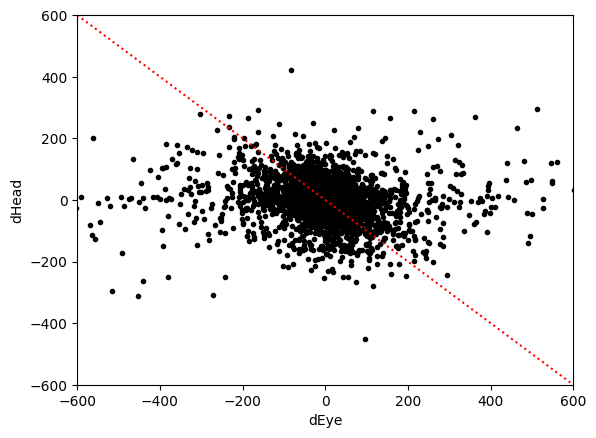

In [57]:
plt.plot(dEye_dps[::20], dHead[::20], 'k.')
plt.xlabel('dEye')
plt.ylabel('dHead')
plt.xlim((-600,600))
plt.ylim((-600,600))
plt.plot([-600,600], [600,-600], 'r:')


In [58]:
# now, it is time to parse gaze shift responses into the large vs. smaller

# calc gaze amp

gazeL_amp = np.zeros(len(gazeL_idx))
gazeR_amp = np.zeros(len(gazeR_idx))

for i in range(len(gazeL_amp)):
    gazeL_amp[i] = np.nanmax(abs(dGaze[gazeL_idx[i]:gazeL_idx[i]+5]))

for i in range(len(gazeR_amp)):
    gazeR_amp[i] = np.nanmax(abs(dGaze[gazeR_idx[i]:gazeR_idx[i]+5]))

# gather every dHead/dEye single events

gazeL_dhead = np.zeros([len(gazeL_idx),61]) #30 bins are 1s (i.e., 16ms of EyeCam)
for i in range(0, len(gazeL_idx)):
    gazeL_dhead[i,:] = dHead[gazeL_idx[i]-30:gazeL_idx[i]+31]

gazeL_deye = np.zeros([len(gazeL_event),61])
for i in range(0, len(gazeL_event)):
    gazeL_deye[i,:] = dEye_dps[gazeL_idx[i]-30:gazeL_idx[i]+31]

gazeR_dhead = np.zeros([len(gazeR_idx),61])
for i in range(0, len(gazeR_idx)):
    gazeR_dhead[i,:] = dHead[gazeR_idx[i]-30:gazeR_idx[i]+31]

gazeR_deye = np.zeros([len(gazeR_idx),61])
for i in range(0, len(gazeR_idx)):
    gazeR_deye[i,:] = dEye_dps[gazeR_idx[i]-30:gazeR_idx[i]+31]


Text(0, 0.5, 'event #')

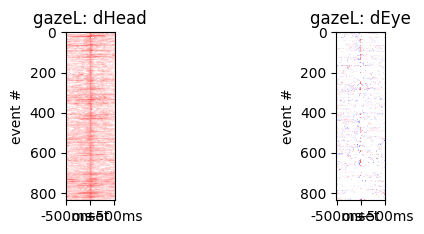

In [59]:
#event-by-event dHead/dEye dynamics
plt.subplot(2,2,1)
plt.imshow(gazeL_dhead, cmap = 'seismic', aspect = 0.25)
x_tick_locations = [0,30,60]
x_tick_labels = ['-500ms', 'onset', '+500ms']
plt.xticks(x_tick_locations, x_tick_labels)     
plt.ylabel('event #')

plt.title('gazeL: dHead')
plt.subplot(2,2,2)
plt.imshow(gazeL_deye, cmap = 'seismic', aspect = 0.25)
plt.title('gazeL: dEye')
plt.xticks(x_tick_locations, x_tick_labels)   
plt.ylabel('event #')



Text(0.5, 0, 'time (ms)')

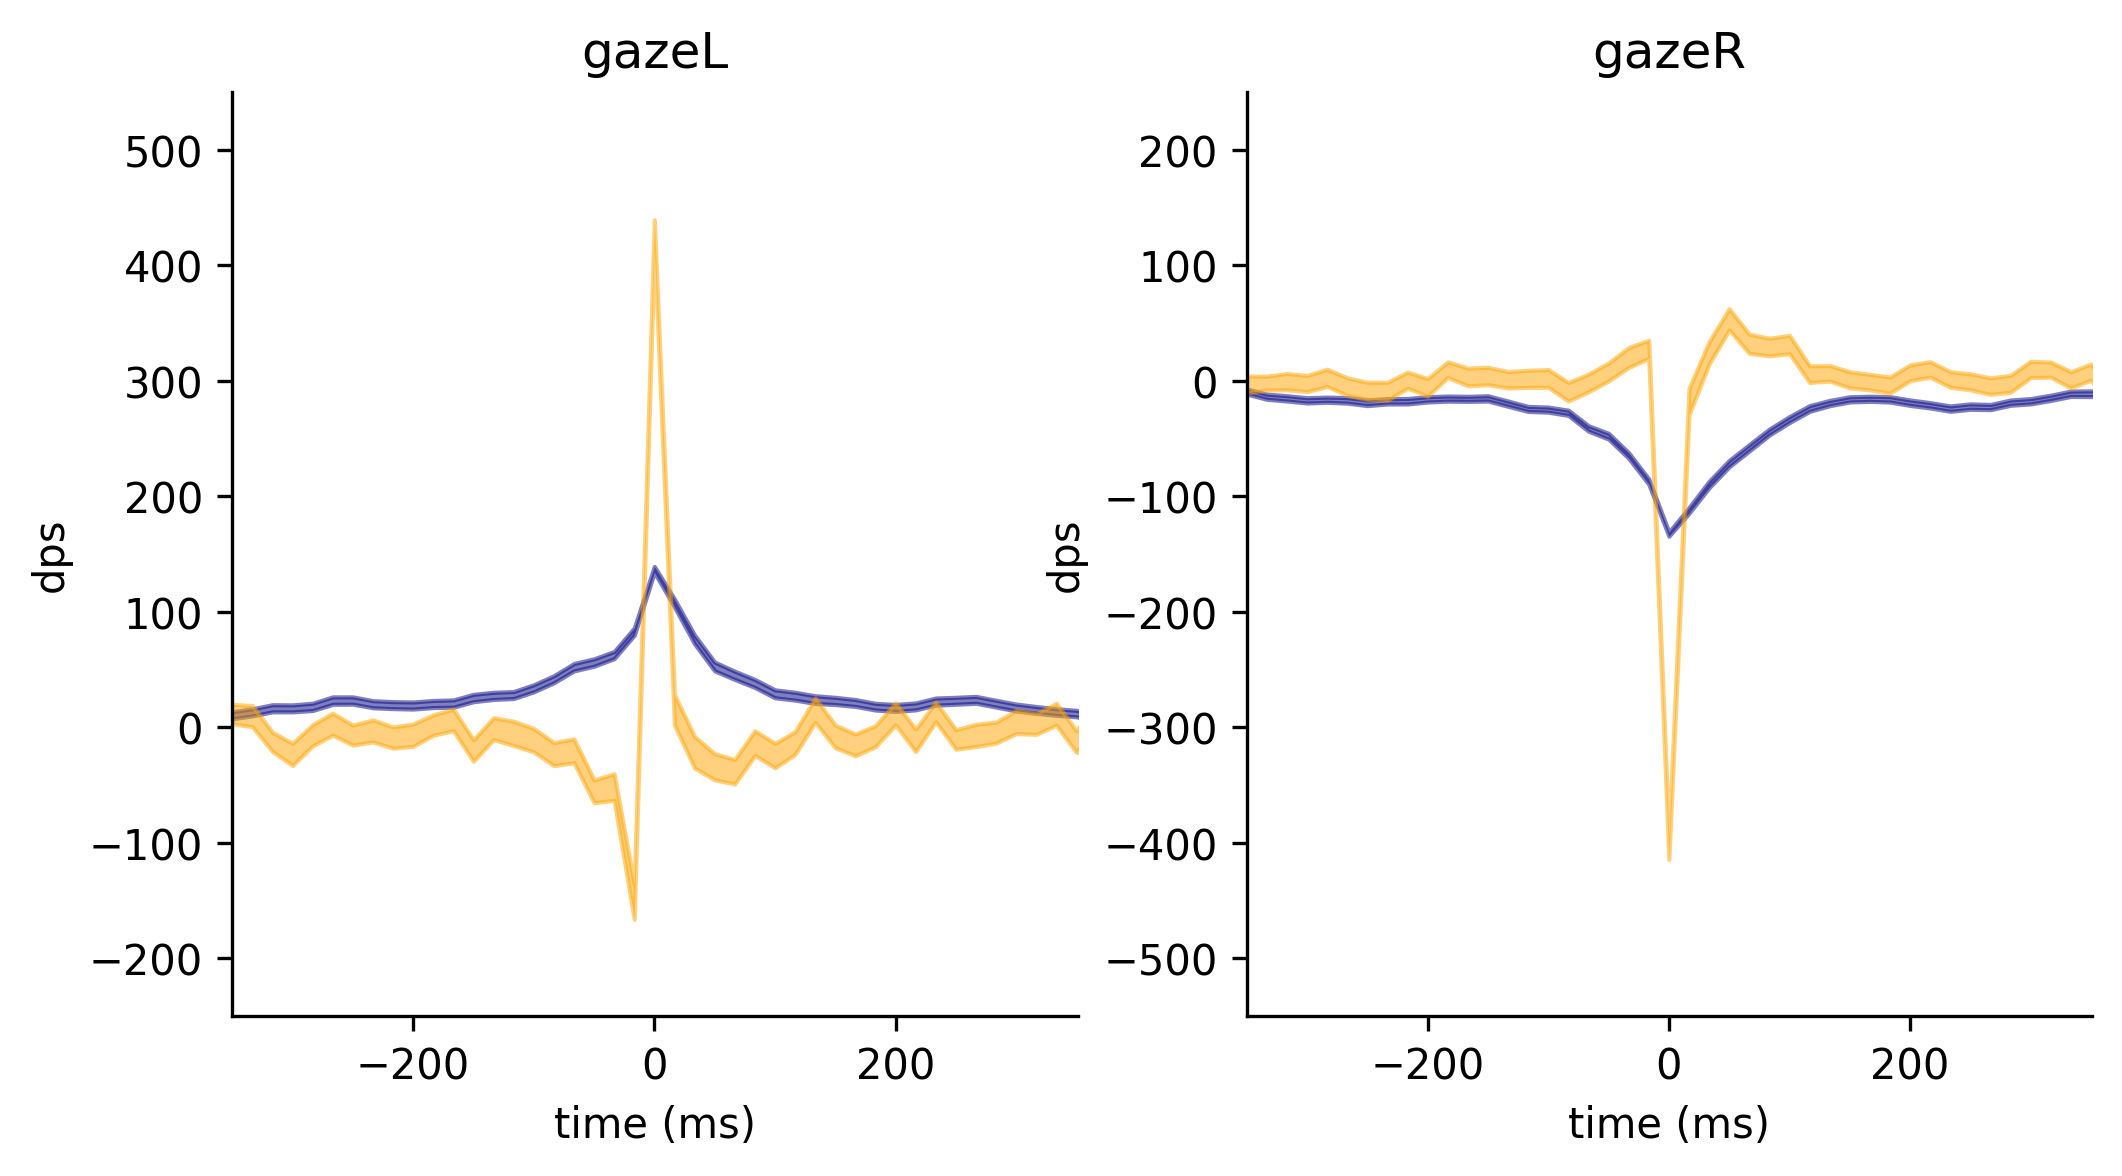

In [60]:


fig, [ax0,ax1] = plt.subplots(1,2,figsize=(8,4), dpi=300)
x_time = np.linspace(-500,500,61)
y = np.nanmean(gazeL_dhead,0)
e =  stats.sem(gazeL_dhead, nan_policy = 'omit')

ax0.fill_between(x_time, y-e, y+e, alpha = 0.5, edgecolor='navy', facecolor='navy')

y = np.nanmean(gazeL_deye,0)
e =  stats.sem(gazeL_deye, nan_policy = 'omit')
ax0.fill_between(x_time, y-e, y+e, alpha = 0.5, edgecolor='orange', facecolor='orange')

ax0.spines[['right', 'top']].set_visible(False)  
ax0.set_xlim([-350, 351])
ax0.set_ylim([-250, 550])
ax0.set_xlabel('time (ms)')
ax0.set_ylabel('dps')
ax0.set_title('gazeL', fontsize=12)

y = np.nanmean(gazeR_dhead,0)
e =  stats.sem(gazeR_dhead, nan_policy = 'omit')

ax1.fill_between(x_time, y-e, y+e, alpha = 0.5, edgecolor='navy', facecolor='navy')

y = np.nanmean(gazeR_deye,0)
e =  stats.sem(gazeR_deye, nan_policy = 'omit')
ax1.fill_between(x_time, y-e, y+e, alpha = 0.5, edgecolor='orange', facecolor='orange')

ax1.spines[['right', 'top']].set_visible(False)  
ax1.set_xlim([-350, 351])
ax1.set_ylim([-550, 250])

ax1.set_ylabel('dps')
ax1.set_title('gazeR', fontsize=12)
ax1.set_xlabel('time (ms)')


Text(0.5, 1.0, 'smaller gaze')

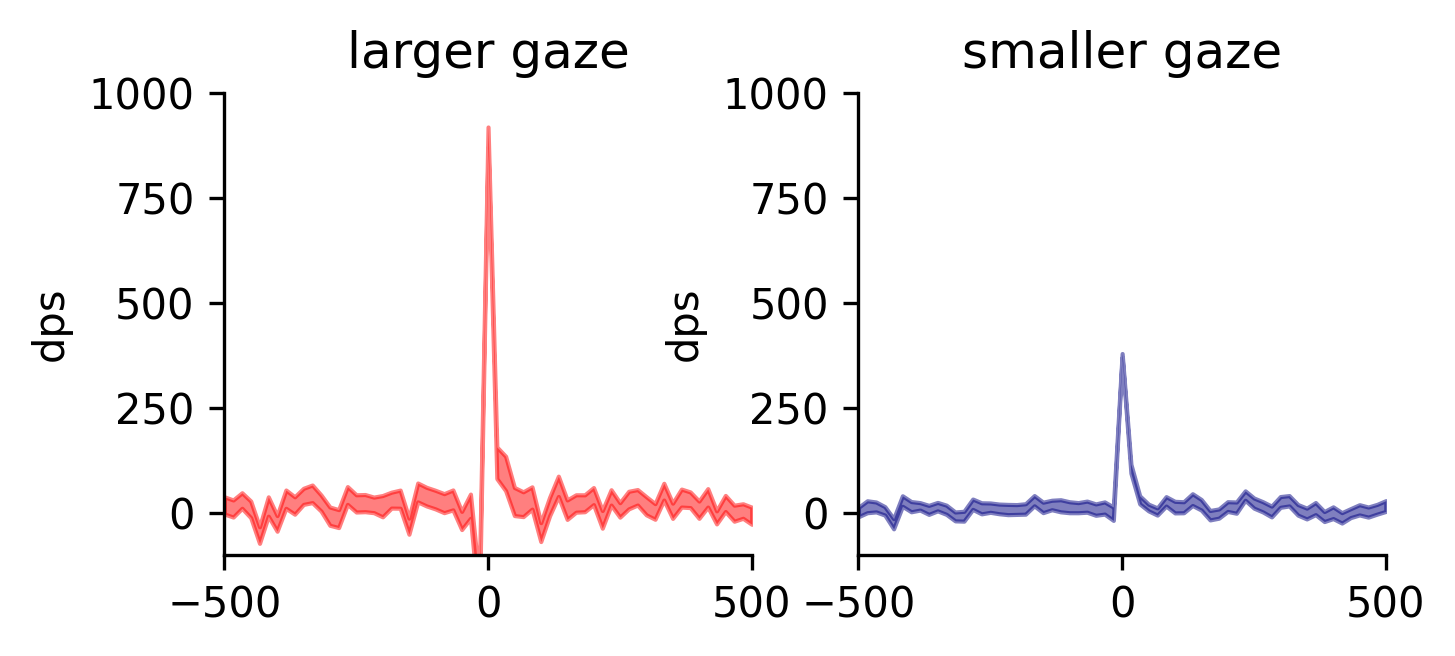

In [61]:


fig, [ax0,ax1] = plt.subplots(1,2,figsize=(5,2), dpi=300)
x_time = np.linspace(-500,500,61)
y = np.nanmean(gazeL_dhead[np.where(gazeL_amp >= 800)]+gazeL_deye[np.where(gazeL_amp >= 800)],0)
e =  stats.sem(gazeL_dhead[np.where(gazeL_amp >= 800)]+gazeL_deye[np.where(gazeL_amp >= 800)], nan_policy = 'omit')

ax0.fill_between(x_time, y-e, y+e, alpha = 0.5, edgecolor='red', facecolor='red')
ax0.spines[['right', 'top']].set_visible(False)  
ax0.set_xlim([-501, 501])
ax0.set_ylim([-100, 1000])

ax0.set_ylabel('dps')
ax0.set_title('larger gaze', fontsize=12)

y = np.nanmean(gazeL_dhead[np.where(gazeL_amp < 600)]+gazeL_deye[np.where(gazeL_amp < 600)],0)
e =  stats.sem(gazeL_dhead[np.where(gazeL_amp < 600)]+gazeL_deye[np.where(gazeL_amp < 600)], nan_policy = 'omit')


ax1.fill_between(x_time, y-e, y+e, alpha = 0.5, edgecolor='navy', facecolor='navy')
ax1.spines[['right', 'top']].set_visible(False)  
ax1.set_xlim([-501, 501])
ax1.set_ylim([-100, 1000])

ax1.set_ylabel('dps')
ax1.set_title('smaller gaze', fontsize=12)


In [ ]:
#interpolate position 

animal_PosX = scipy.interpolate.interp1d(topT,
                                    led_x_coord,
                                    bounds_error=False)(eyeT)[:-1]

animal_PosY = scipy.interpolate.interp1d(topT,
                                    led_y_coord,
                                    bounds_error=False)(eyeT)[:-1]

plt.plot(animal_PosX, animal_PosY,'k.', markersize = 0.75, alpha = 0.5)
plt.plot(animal_PosX[gazeL_idx], animal_PosY[gazeL_idx],'r.', markersize = 3, alpha = 0.8)
plt.plot(animal_PosX[gazeR_idx], animal_PosY[gazeR_idx],'b.', markersize = 3, alpha = 0.9)

plt.xlim([25,825])
plt.ylim([75,575])
